In [ ]:
from discminer.emulator import Emulator
import discminer.emulator as emulib
import torch
import numpy as np
#loading the datacube under exam
from discminer.core import Data
from sys import path as syspath
from astropy import units as u
import json
import matplotlib.pyplot as plt
from discminer.mining_utils import get_noise_mask, init_data_and_model

In [ ]:
#load data
import pandas as pd
params_test = pd.read_csv('../data/data/gas_tri_256/testpara.csv')
emu_data_vr = np.load('../results/data/vr_256/1980.npy')
emu_data_vphi = np.load('../results/data/vaz_256/1800.npy')
testset_data = np.load('../data/data/gas_tri_256/datatest.npy')
xy = np.linspace(-3,3,256)
xx, yy = np.meshgrid(xy, xy)
rrr = np.sqrt(xx**2+yy**2)
mask = (rrr>0.4) & (rrr<3)

# Generation of the cmaps

In [14]:
datacube, model = init_data_and_model(Rmin=0, Rmax=1, parfile='parfile.json', )
simid = 20
import discminer.units as ucf
emu_params = {
        'alpha': params_test.loc[simid, 'Alpha'],
        'h': params_test.loc[simid, 'AspectRatio'],
        'planetMass': params_test.loc[simid, 'PlanetMass'],
        'sigmaSlope': params_test.loc[simid, 'SigmaSlope'],
        'flaringIndex': params_test.loc[simid, 'FlaringIndex'],
        'R_p': 400*ucf.au,
        'phi_p': np.pi,
        'extrap_vfunc': model.keplerian
    }

import torch
def vr_norm(data):
    return data * 1e-2


xy = np.linspace(-3, 3, 256)
xx, yy = np.meshgrid(xy, xy)
rr = np.sqrt(xx**2 + yy**2)
rr = torch.tensor(rr, dtype=torch.float)

def vaz_norm(data):
    return data * 1e-2 + rr**-0.5


labels = ["vphi", "vr"]
pths = [
    "../../../SCIENCE/UnetEmu/outputs/vphi_256/model__epoch_1980_test_vaz_256.pth",
    "../../../SCIENCE/UnetEmu/outputs/vr_256/model__epoch_1980_test_vr_256.pth",
]
params = [
    "../../../SCIENCE/UnetEmu/outputs/vphi_256/params.py",
    "../../../SCIENCE/UnetEmu/outputs/vr_256/params.py",
]
norm_funcs = [vaz_norm, vr_norm]
emu = Emulator(
    model_pths=pths,
    labels=["vphi", "vr"],
    model_params=params,
    norm_funcs=norm_funcs,
    ict_gen=emulib.generate_ict_128x128_disc_tri_slopes,
)

     _  _                        _                    
  __| |(_) ___   ___  _ __ ___  (_) _ __    ___  _ __ 
 / _` || |/ __| / __|| '_ ` _ \ | || '_ \  / _ \| '__|
| (_| || |\__ \| (__ | | | | | || || | | ||  __/| |   
 \__,_||_||___/ \___||_| |_| |_||_||_| |_| \___||_|   
                                                      

*====================================================================================================*
Computing grid...
Grid maximum extent: 120689578165943.16
Grid step (cell size): 969394202136.0896
*====================================================================================================*
*====================================================================================================*
Computing grid...
Grid maximum extent: 107118059336037.9
Grid step (cell size): 969394202136.0896
*====================================================================================================*
Setting beam_info var to Beam: BMAJ=0.165413767099392 arcsec

### Generate channel maps from emulator

In [27]:
from discminer import units as ucf
from tqdm import tqdm

model.velocity_func = emu.emulate_v2d
model.params['orientation']['incl'] = np.pi/4

modelcubes = []
for simid in tqdm([simid]):
    emu_params = {
        'alpha': params_test.loc[simid, 'Alpha'],
        'h': params_test.loc[simid, 'AspectRatio'],
        'planetMass': params_test.loc[simid, 'PlanetMass'],
        'sigmaSlope': params_test.loc[simid, 'SigmaSlope'],
        'flaringIndex': params_test.loc[simid, 'FlaringIndex'],
        'R_p': 400*ucf.au,
        'phi_p': np.pi/4,
        'extrap_vfunc': model.keplerian
    }
    model.params['velocity'].update(emu_params)
    modelcube = model.make_model(make_convolve=False)
    modelcube.convert_to_tb()
    modelcubes.append(modelcube.data)

Setting velocity function to <bound method Emulator.emulate_v2d of <discminer.emulator.Emulator object at 0x7ff591f73460>>


  0%|          | 0/1 [00:00<?, ?it/s]

*====================================================================================================*
Running prototype model with the following parameters:

{'height_lower': {'Rb': 803.90594,
                  'p': 1.107099,
                  'q': 2.859784,
                  'z0': 14.227028},
 'height_upper': {'Rb': 108.607483,
                  'p': 1.65208,
                  'q': 0.550336,
                  'z0': 52.680114},
 'intensity': {'I0': 0.10439999999999999,
               'Rout': 717.971915,
               'p': -2.659016,
               'q': 2.156254},
 'lineslope': {'Ls': 1.676401, 'p': 0.314061},
 'linewidth': {'L0': 0.316459, 'p': -0.288951, 'q': -0.355926},
 'orientation': {'PA': 1.010296,
                 'incl': 0.7853981633974483,
                 'xc': -0.91338,
                 'yc': -1.826827},
 'velocity': {'Mstar': 1.973085,
              'R_p': 59839148280000.0,
              'alpha': 0.0053703179637025,
              'extrap_vfunc': <function Velocity.kepleri

100%|██████████| 1/1 [00:21<00:00, 21.23s/it]


In [28]:
modelcubes_arr_emu = np.array(modelcubes)

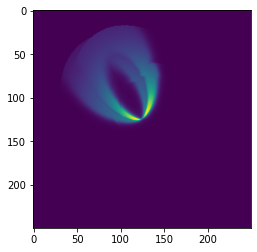

In [43]:
plt.imshow(modelcubes_arr_emu[0,60])

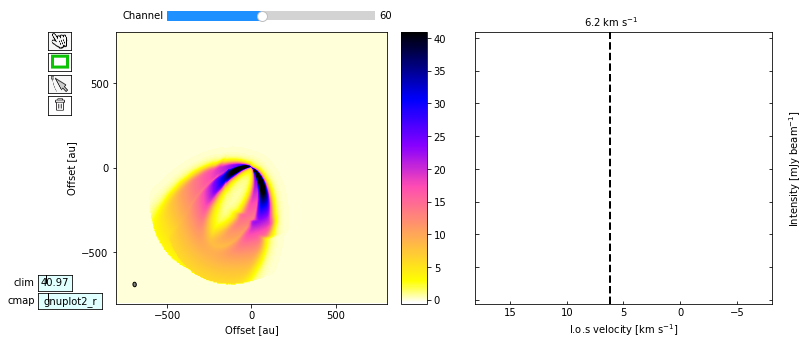

In [34]:
modelcube.show(chan_init=60)

### Generate cmaps from simulations

In [47]:
from scipy.interpolate import griddata
from discminer import units as u
testset_data = np.load('../data/data/gas_tri_256/datatest.npy')
def hypot_func(x, y): return np.sqrt(xx**2+yy**2)
def per_b(t):
        shape = t.shape
        t = t.flatten()
        t[t > np.pi] = t[t > np.pi] - 2 * np.pi
        t[t < -np.pi] = t[t < -np.pi] + 2 * np.pi
        return t.reshape(*shape)
def simulations_v2d(
        coord,
        R_p,
        phi_p,
        simid,
        extrap_vfunc,
        **extrap_kwargs,
    ):

        G = 6.67384e-11
        if "Mstar" in extrap_kwargs.keys():
            Mstar = extrap_kwargs["Mstar"]
        else:
            Mstar = 1

        if "v_sign" in extrap_kwargs.keys():
            v_sign = extrap_kwargs["v_sign"]
        else:
            v_sign = 1

        v3d = testset_data[simid,[1,2]]
        v3d = v3d[:, :, ::-1]

        x = np.linspace(-3, 3, 256)
        y = np.linspace(-3, 3, 256)
        xx, yy = np.meshgrid(x, y)

        rr = hypot_func(xx, yy)
        pp = np.arctan2(yy, xx)
        rr_dom = rr[(rr > 0.5) & (rr < 2.9)] * R_p
        pp_dom = per_b(pp[(rr > 0.5) & (rr < 2.9)] + phi_p)
        v3d_dom = v3d[:, (rr > 0.5) & (rr < 2.9)]
        x_dom = rr_dom * np.cos(pp_dom)
        y_dom = rr_dom * np.sin(pp_dom)

        if "R" not in coord.keys():
            R = hypot_func(coord["x"], coord["y"])
        else:
            R = coord["R"]

        if "phi" not in coord.keys():
            phi = np.arctan2(coord["x"], coord["y"])
        else:
            phi = coord["phi"]

        vphi_interp = (
            (
                griddata(
                    (x_dom, y_dom), v3d_dom[0].reshape(-1), (coord["x"], coord["y"])
                )
                * np.sqrt(G * Mstar * u.MSun / R_p)
            )
            * 1e-3
            * (-1)
            * v_sign
        )
        vr_interp = (
            griddata((x_dom, y_dom), v3d_dom[1].reshape(-1), (coord["x"], coord["y"]))
            * 1e-3
        )

        mask = (R > 2.9 * R_p) | (R < 0.5 * R_p)
        vphi_interp[mask] = extrap_vfunc(coord, **extrap_kwargs)[mask]
        vr_interp[mask] = 0
        v3d_interp = np.concatenate(
            [
                np.expand_dims(vphi_interp, axis=0),
                np.expand_dims(vr_interp, axis=0),
                -np.zeros((1, *vphi_interp.shape)) * v_sign,
            ],
            axis=0,
        )

        return v3d_interp

In [50]:
from discminer import units as ucf
from tqdm import tqdm
datacube, model = init_data_and_model(Rmin=0, Rmax=1, parfile='parfile.json', )
emu_params = {
    'simid': 0,
    'R_p': 400*ucf.au,
    'phi_p':np.pi/4,
    'extrap_vfunc': model.keplerian
}
model.velocity_func = simulations_v2d
model.params['orientation']['incl'] = np.pi/4
model.params['velocity'].update(emu_params)
modelcubes_sim = []
for i in tqdm([simid]):
    model.params['velocity']['simid'] = i
    modelcube = model.make_model(make_convolve=False)
    modelcube.convert_to_tb()
    modelcubes_sim.append(np.expand_dims(modelcube.data, axis=0))


     _  _                        _                    
  __| |(_) ___   ___  _ __ ___  (_) _ __    ___  _ __ 
 / _` || |/ __| / __|| '_ ` _ \ | || '_ \  / _ \| '__|
| (_| || |\__ \| (__ | | | | | || || | | ||  __/| |   
 \__,_||_||___/ \___||_| |_| |_||_||_| |_| \___||_|   
                                                      

*====================================================================================================*
Computing grid...
Grid maximum extent: 120689578165943.16
Grid step (cell size): 969394202136.0896
*====================================================================================================*
*====================================================================================================*
Computing grid...
Grid maximum extent: 107118059336037.9
Grid step (cell size): 969394202136.0896
*====================================================================================================*
Setting beam_info var to Beam: BMAJ=0.165413767099392 arcsec

  0%|          | 0/1 [00:00<?, ?it/s]

*====================================================================================================*
Running prototype model with the following parameters:

{'height_lower': {'Rb': 803.90594,
                  'p': 1.107099,
                  'q': 2.859784,
                  'z0': 14.227028},
 'height_upper': {'Rb': 108.607483,
                  'p': 1.65208,
                  'q': 0.550336,
                  'z0': 52.680114},
 'intensity': {'I0': 0.10439999999999999,
               'Rout': 717.971915,
               'p': -2.659016,
               'q': 2.156254},
 'lineslope': {'Ls': 1.676401, 'p': 0.314061},
 'linewidth': {'L0': 0.316459, 'p': -0.288951, 'q': -0.355926},
 'orientation': {'PA': 1.010296,
                 'incl': 0.7853981633974483,
                 'xc': -0.91338,
                 'yc': -1.826827},
 'velocity': {'Mstar': 1.973085,
              'R_p': 59839148280000.0,
              'extrap_vfunc': <function Velocity.keplerian at 0x7ff48c3ef6d0>,
              'phi_p

100%|██████████| 1/1 [00:14<00:00, 14.87s/it]


In [51]:
modelcubes_arr_sim = np.concatenate(modelcubes, axis=0)

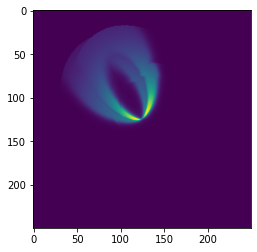

In [54]:
plt.imshow(modelcubes_arr_sim[60])

# comparison

In [56]:
modelcubes_arr_sim.shape

(133, 250, 250)

In [58]:
modelcubes_arr_emu = modelcubes_arr_emu[0]

In [65]:
mse = ((modelcubes_arr_emu-modelcubes_arr_sim))

In [47]:
res = modelcubes_arr[[1],48:84]-modelcubes_sim[:, 48:84]

In [66]:
np.max(np.abs(mse))

0.0

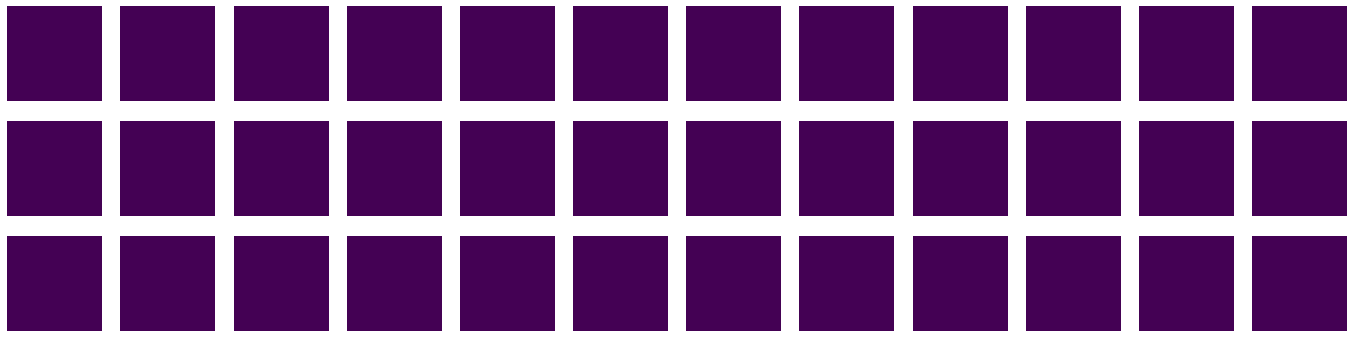

In [62]:
fig, axs = plt.subplots(3,12,figsize=(24,6))
axs = axs.flatten()
for i in range(36):
    axs[i].imshow(mse[i], )
    axs[i].axis('off')

In [68]:
plt.scatter(range(1), (res**2).mean(axis=(1,2,3)))

AxisError: axis 3 is out of bounds for array of dimension 3

# Generate cmaps from precomputed emulations

In [1]:
emu_data_vphi.shape

NameError: name 'emu_data_vphi' is not defined

In [ ]:
from scipy.interpolate import griddata
from discminer import units as u
emu_data_vr = np.load('../results/data/vr_256/1980.npy')
emu_data_vphi = np.load('../results/data/vaz_256/1800.npy')
def hypot_func(x, y): return np.sqrt(xx**2+yy**2)
def per_b(t):
        shape = t.shape
        t = t.flatten()
        t[t > np.pi] = t[t > np.pi] - 2 * np.pi
        t[t < -np.pi] = t[t < -np.pi] + 2 * np.pi
        return t.reshape(*shape)
def simulations_v2d(
        coord,
        R_p,
        phi_p,
        simid,
        extrap_vfunc,
        **extrap_kwargs,
    ):

        G = 6.67384e-11
        if "Mstar" in extrap_kwargs.keys():
            Mstar = extrap_kwargs["Mstar"]
        else:
            Mstar = 1

        if "v_sign" in extrap_kwargs.keys():
            v_sign = extrap_kwargs["v_sign"]
        else:
            v_sign = 1

        v3d = np.concatenate([emu_data_vphi[simid], emu_data_vr[simid]], axis=0)
        v3d = v3d[:, :, ::-1]

        x = np.linspace(-3, 3, 256)
        y = np.linspace(-3, 3, 256)
        xx, yy = np.meshgrid(x, y)

        rr = hypot_func(xx, yy)
        pp = np.arctan2(yy, xx)
        rr_dom = rr[(rr > 0.5) & (rr < 2.9)] * R_p
        pp_dom = per_b(pp[(rr > 0.5) & (rr < 2.9)] + phi_p)
        v3d_dom = v3d[:, (rr > 0.5) & (rr < 2.9)]
        x_dom = rr_dom * np.cos(pp_dom)
        y_dom = rr_dom * np.sin(pp_dom)

        if "R" not in coord.keys():
            R = hypot_func(coord["x"], coord["y"])
        else:
            R = coord["R"]

        if "phi" not in coord.keys():
            phi = np.arctan2(coord["x"], coord["y"])
        else:
            phi = coord["phi"]

        vphi_interp = (
            (
                griddata(
                    (x_dom, y_dom), v3d_dom[0].reshape(-1), (coord["x"], coord["y"])
                )
                * np.sqrt(G * Mstar * u.MSun / R_p)
            )
            * 1e-3
            * (-1)
            * v_sign
        )
        vr_interp = (
            griddata((x_dom, y_dom), v3d_dom[1].reshape(-1), (coord["x"], coord["y"]))
            * 1e-3
        )

        mask = (R > 2.9 * R_p) | (R < 0.5 * R_p)
        vphi_interp[mask] = extrap_vfunc(coord, **extrap_kwargs)[mask]
        vr_interp[mask] = 0
        v3d_interp = np.concatenate(
            [
                np.expand_dims(vphi_interp, axis=0),
                np.expand_dims(vr_interp, axis=0),
                -np.zeros((1, *vphi_interp.shape)) * v_sign,
            ],
            axis=0,
        )

        return v3d_interp

In [84]:
datacube, model = init_data_and_model(Rmin=0, Rmax=1, parfile='parfile.json')

     _  _                        _                    
  __| |(_) ___   ___  _ __ ___  (_) _ __    ___  _ __ 
 / _` || |/ __| / __|| '_ ` _ \ | || '_ \  / _ \| '__|
| (_| || |\__ \| (__ | | | | | || || | | ||  __/| |   
 \__,_||_||___/ \___||_| |_| |_||_||_| |_| \___||_|   
                                                      

*====================================================================================================*
Computing grid...
Grid maximum extent: 120689578165943.16
Grid step (cell size): 969394202136.0896
*====================================================================================================*
*====================================================================================================*
Computing grid...
Grid maximum extent: 107118059336037.9
Grid step (cell size): 969394202136.0896
*====================================================================================================*
Setting beam_info var to Beam: BMAJ=0.165413767099392 arcsec

In [85]:
from discminer import units as ucf
from tqdm import tqdm

emu_params = {
    'simid': 0,
    'R_p': 400*ucf.au,
    'phi_p':np.pi/4,
    'extrap_vfunc': model.keplerian
}
model.params['velocity'].update(emu_params)
model.velocity_func = simulations_v2d
model.params['orientation']['incl'] = np.pi/4

modelcubes = []
for simid in tqdm(range(0, 10)):
    model.params['velocity']['simid'] = simid
    modelcube = model.make_model(make_convolve=False)
    modelcube.convert_to_tb()
    modelcubes.append(np.expand_dims(modelcube.data, axis=0))

Setting velocity function to <function simulations_v2d at 0x7f7823e21a20>


  0%|          | 0/10 [00:00<?, ?it/s]

*====================================================================================================*
Running prototype model with the following parameters:

{'height_lower': {'Rb': 803.90594,
                  'p': 1.107099,
                  'q': 2.859784,
                  'z0': 14.227028},
 'height_upper': {'Rb': 108.607483,
                  'p': 1.65208,
                  'q': 0.550336,
                  'z0': 52.680114},
 'intensity': {'I0': 0.10439999999999999,
               'Rout': 717.971915,
               'p': -2.659016,
               'q': 2.156254},
 'lineslope': {'Ls': 1.676401, 'p': 0.314061},
 'linewidth': {'L0': 0.316459, 'p': -0.288951, 'q': -0.355926},
 'orientation': {'PA': 1.010296,
                 'incl': 0.7853981633974483,
                 'xc': -0.91338,
                 'yc': -1.826827},
 'velocity': {'Mstar': 1.973085,
              'R_p': 59839148280000.0,
              'extrap_vfunc': <function Velocity.keplerian at 0x7f7955dafac0>,
              'phi_p

 10%|█         | 1/10 [00:12<01:56, 12.93s/it]

*====================================================================================================*
Running prototype model with the following parameters:

{'height_lower': {'Rb': 803.90594,
                  'p': 1.107099,
                  'q': 2.859784,
                  'z0': 14.227028},
 'height_upper': {'Rb': 108.607483,
                  'p': 1.65208,
                  'q': 0.550336,
                  'z0': 52.680114},
 'intensity': {'I0': 0.10439999999999999,
               'Rout': 717.971915,
               'p': -2.659016,
               'q': 2.156254},
 'lineslope': {'Ls': 1.676401, 'p': 0.314061},
 'linewidth': {'L0': 0.316459, 'p': -0.288951, 'q': -0.355926},
 'orientation': {'PA': 1.010296,
                 'incl': 0.7853981633974483,
                 'xc': -0.91338,
                 'yc': -1.826827},
 'velocity': {'Mstar': 1.973085,
              'R_p': 59839148280000.0,
              'extrap_vfunc': <function Velocity.keplerian at 0x7f7955dafac0>,
              'phi_p

...

 80%|████████  | 8/10 [01:53<00:28, 14.01s/it]

*====================================================================================================*
Running prototype model with the following parameters:

{'height_lower': {'Rb': 803.90594,
                  'p': 1.107099,
                  'q': 2.859784,
                  'z0': 14.227028},
 'height_upper': {'Rb': 108.607483,
                  'p': 1.65208,
                  'q': 0.550336,
                  'z0': 52.680114},
 'intensity': {'I0': 0.10439999999999999,
               'Rout': 717.971915,
               'p': -2.659016,
               'q': 2.156254},
 'lineslope': {'Ls': 1.676401, 'p': 0.314061},
 'linewidth': {'L0': 0.316459, 'p': -0.288951, 'q': -0.355926},
 'orientation': {'PA': 1.010296,
                 'incl': 0.7853981633974483,
                 'xc': -0.91338,
                 'yc': -1.826827},
 'velocity': {'Mstar': 1.973085,
              'R_p': 59839148280000.0,
              'extrap_vfunc': <function Velocity.keplerian at 0x7f7955dafac0>,
              'phi_p

 90%|█████████ | 9/10 [02:06<00:13, 13.66s/it]

*====================================================================================================*
Running prototype model with the following parameters:

{'height_lower': {'Rb': 803.90594,
                  'p': 1.107099,
                  'q': 2.859784,
                  'z0': 14.227028},
 'height_upper': {'Rb': 108.607483,
                  'p': 1.65208,
                  'q': 0.550336,
                  'z0': 52.680114},
 'intensity': {'I0': 0.10439999999999999,
               'Rout': 717.971915,
               'p': -2.659016,
               'q': 2.156254},
 'lineslope': {'Ls': 1.676401, 'p': 0.314061},
 'linewidth': {'L0': 0.316459, 'p': -0.288951, 'q': -0.355926},
 'orientation': {'PA': 1.010296,
                 'incl': 0.7853981633974483,
                 'xc': -0.91338,
                 'yc': -1.826827},
 'velocity': {'Mstar': 1.973085,
              'R_p': 59839148280000.0,
              'extrap_vfunc': <function Velocity.keplerian at 0x7f7955dafac0>,
              'phi_p

100%|██████████| 10/10 [02:20<00:00, 14.02s/it]


In [86]:
mmarr = np.array(modelcubes)

In [87]:
mmarr.shape

(10, 1, 133, 250, 250)

In [89]:
res = mmarr[[1],0, 48:84]-modelcubes_sim[:, 48:84]

In [91]:
res.mean(axis=(1,2,3))

array([0.01372405, 0.01407135, 0.01672631, 0.01367052, 0.0138173 ,
       0.01612652, 0.01348852, 0.01368568, 0.01361025, 0.01654578])

In [92]:
mmarr.shape

(10, 1, 133, 250, 250)

In [93]:
modelcubes_sim.shape

(10, 133, 250, 250)

In [94]:
emu_data_vphi.shape

(233, 1, 256, 256)

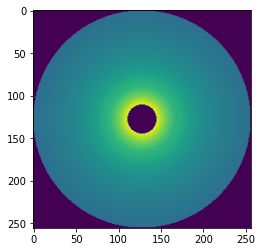

In [108]:
xy = np.linspace(-3,3,256)
xx, yy = np.meshgrid(xy, xy)
rr = np.sqrt(xx**2+yy**2)
mask = (rr>0.4) & (rr<3)
plt.imshow()

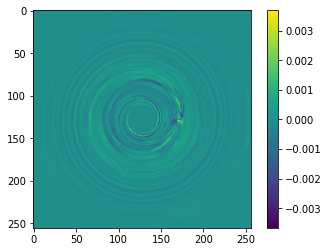

In [110]:
plt.imshow(testset_data[0,1]-(emu_data_vphi[0,0]*1e-2+rr**-0.5)*mask)
plt.colorbar()

In [111]:
emu_data_vphi.mean()

-0.09008781

# Test of cmaps generation with hd163296 file

In [1]:
from discminer.emulator import Emulator
from scipy.interpolate import griddata
import discminer.emulator as emulib
import torch
import numpy as np
import pandas as pd
from fforge.utils import units as u

# loading the datacube under exam
from discminer.core import Data
from sys import path as syspath
import json
from discminer import units as ucf
from tqdm import tqdm
import matplotlib.pyplot as plt
from discminer.mining_utils import get_noise_mask, init_data_and_model
from scipy.interpolate import RegularGridInterpolator
from discminer.diff_interp import get_griddata_sparse

In [31]:
cmaps = np.load('cmaps_from_simulations_testset_parfile_R261_phi0.99_hd163296like2.npy')

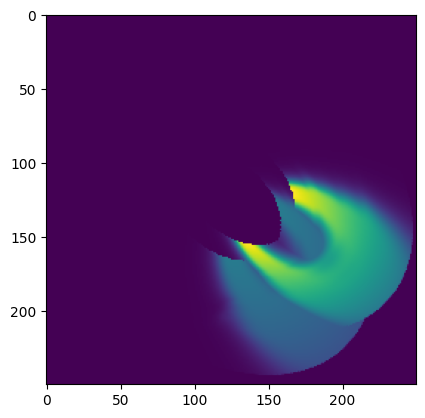

In [33]:
plt.imshow(cmaps[0, 60])

In [25]:
cmaps.shape

(233, 91, 250, 250)

In [12]:
Rp = 261 #au
phi_p = 57*np.pi/180

#load the testset
testset_data = '../data/data/data/gas_tri_256/datatest.npy'
testset = np.load(testset_data)[:,[1,2],::-1] #loads data of the testset with the correct sign

#setup discminer
import get_hd163296_refmodel as getmo
model = getmo.get_model().model

    


In [13]:
cmap = model.make_model()

*====================================================================================================*
Running prototype model with the following parameters:

{'height_lower': {'Rb': 0.03, 'p': 1.09, 'q': 4.18, 'z0': 19.91},
 'height_upper': {'Rb': 4.36, 'p': 1.21, 'q': 1.98, 'z0': 29.78},
 'intensity': {'I0': 8.23, 'Rout': 380, 'p': -4.16, 'q': 3.68},
 'lineslope': {'Ls': 1.85, 'p': 0.21, 'q': 0.0},
 'linewidth': {'L0': 0.08, 'p': 0.86, 'q': -1.38},
 'orientation': {'PA': 0.7391469382195985,
                 'incl': 0.7977900010866079,
                 'xc': 0.0,
                 'yc': 0.0},
 'velocity': {'Mstar': 2.02,
              'R_p': 39045044252700.0,
              'alpha': np.float64(0.0014791083881682),
              'extrap_vfunc': <function keplerian at 0x7f5b313c17e0>,
              'flaringIndex': np.float64(0.09975),
              'h': np.float64(0.04435),
              'mask_only_ppos': False,
              'phi_p': 0.9948376736367678,
              'planetMass': np.flo

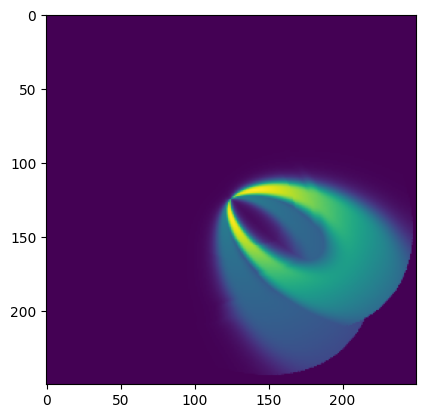

In [14]:
plt.imshow(cmap.data[60])

In [15]:
import genCMAP_fromsimulations as gg

In [16]:
# setup discminer
model.velocity_func = gg.simulations_v2d

    

Setting velocity function to <function simulations_v2d at 0x7f5b19d85630>


In [17]:
cmaps = []
cmaps.append(gg.generate_cmap(testset[0], model, Rp, phi_p, False, mask_only_ppos=False))
cmaps = np.array(cmaps)

*====================================================================================================*
Running prototype model with the following parameters:

{'height_lower': {'Rb': 0.03, 'p': 1.09, 'q': 4.18, 'z0': 19.91},
 'height_upper': {'Rb': 4.36, 'p': 1.21, 'q': 1.98, 'z0': 29.78},
 'intensity': {'I0': 8.23, 'Rout': 380, 'p': -4.16, 'q': 3.68},
 'lineslope': {'Ls': 1.85, 'p': 0.21, 'q': 0.0},
 'linewidth': {'L0': 0.08, 'p': 0.86, 'q': -1.38},
 'orientation': {'PA': 0.7391469382195985,
                 'incl': 0.7977900010866079,
                 'xc': 0.0,
                 'yc': 0.0},
 'velocity': {'Mstar': 2.02,
              'R_p': 39045044252700.0,
              'alpha': np.float64(0.0014791083881682),
              'extrap_vfunc': <function nullv at 0x7f5b19d85120>,
              'flaringIndex': np.float64(0.09975),
              'h': np.float64(0.04435),
              'mask_only_ppos': False,
              'phi_p': 0.9948376736367678,
              'planetMass': np.float64

In [18]:
model.velocity_func

<function genCMAP_fromsimulations.simulations_v2d(coord, R_p, phi_p, v3d, extrap_vfunc, mask_only_ppos=False, interp_3d='SPHERICAL', **extrap_kwargs)>

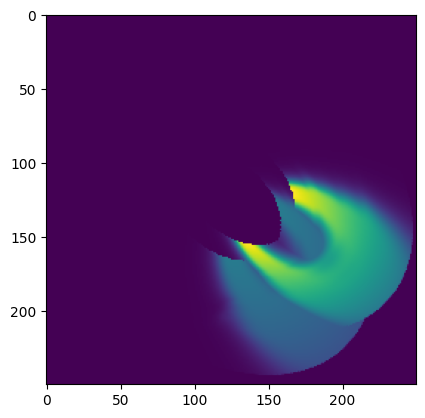

In [19]:
plt.imshow(cmaps[0,60])

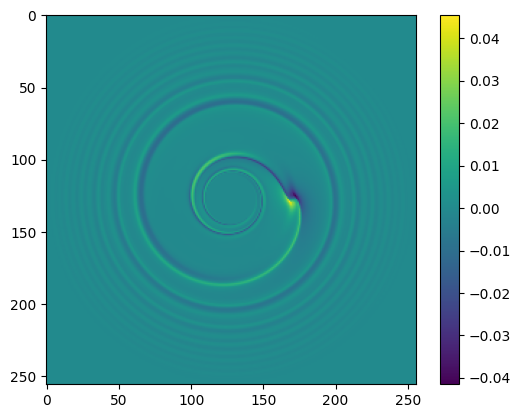

In [11]:
plt.imshow(testset[0, 0])
plt.colorbar()

In [6]:
testset_params = '../data/data/data/gas_tri_256/testpara.csv'
testset = np.load(testset_data)[:,[2,1],::-1] #loads data of the testset with the correct sign
testparams = pd.read_csv(testset_params, index_col=0)
testparams

,InvStokes1,Alpha,AspectRatio,FlaringIndex,PlanetMass,SigmaSlope,nx,rout,ny
0,154.881662,0.001479,0.04435,0.09975,0.000327,0.6995,708.0,3,228.0
1,32.359366,0.000234,0.03525,0.25025,0.002786,1.0005,891.0,3,287.0
2,37.153523,0.002818,0.08635,0.04375,0.005188,0.5875,600.0,5,242.0
3,107.151931,0.001175,0.06045,0.01575,0.000031,0.5315,600.0,3,193.0
4,588.843655,0.006166,0.08565,0.30275,0.000610,1.1055,600.0,3,193.0
...,...,...,...,...,...,...,...,...,...
290,467.735141,0.000933,0.08915,0.23975,0.000010,0.9795,600.0,3,193.0
291,223.872114,0.003890,0.09895,0.34125,0.000027,1.1825,600.0,3,193.0
294,22.387211,0.001778,0.07235,0.30275,0.000164,1.1055,600.0,3,193.0
297,134.896288,0.008128,0.04155,0.09625,0.000124,0.6925,756.0,3,243.0


In [3]:
import fforge
from fforge.inference.emulator import Emulator
from fforge.utils.utils import vr_norm, vaz_norm, generate_ict_128x128_disc_tri_slopes, nullv
#setup emulator
labels = ["vphi", "vr"]
pths = [
    "../trained_models/vphi_256/model__epoch_1980_test_vaz_256.pth",
    "../trained_models/vr_256/model__epoch_1980_test_vr_256.pth",
]
params = [
    "../trained_models/vphi_256/params.py",
    "../trained_models/vr_256/params.py",
]

#functions used to denormalize the emulator output
norm_funcs = [vaz_norm, vr_norm]

emu = Emulator(
    model_pths=pths,
    labels=["vphi", "vr"],
    model_params=params,
    norm_funcs=norm_funcs,
    ict_gen=generate_ict_128x128_disc_tri_slopes,
)
model.velocity_func = emu.emulate_v3d

Setting velocity function to <bound method Emulator.emulate_v3d of <fforge.inference.emulator.Emulator object at 0x7f5b37f0c070>>


In [4]:
testparams

NameError: name 'testparams' is not defined

In [7]:
import discminer
emu_params_sing = {
                    "R_p": Rp * u.au,
                    "phi_p": phi_p,
                    "alpha": testparams.loc[0, 'Alpha'],
                    "h": testparams.loc[0, 'AspectRatio'],
                    "planetMass": testparams.loc[0, 'PlanetMass'],
                    "flaringIndex": testparams.loc[0, 'FlaringIndex'],
                    "extrap_vfunc": discminer.cart.keplerian,
                    "mask_only_ppos": False
             }
        
model.params['velocity'].update(emu_params_sing)  
modelcube = model.make_model(make_convolve=False)


*====================================================================================================*
Running prototype model with the following parameters:

{'height_lower': {'Rb': 0.03, 'p': 1.09, 'q': 4.18, 'z0': 19.91},
 'height_upper': {'Rb': 4.36, 'p': 1.21, 'q': 1.98, 'z0': 29.78},
 'intensity': {'I0': 8.23, 'Rout': 380, 'p': -4.16, 'q': 3.68},
 'lineslope': {'Ls': 1.85, 'p': 0.21, 'q': 0.0},
 'linewidth': {'L0': 0.08, 'p': 0.86, 'q': -1.38},
 'orientation': {'PA': 0.7391469382195985,
                 'incl': 0.7977900010866079,
                 'xc': 0.0,
                 'yc': 0.0},
 'velocity': {'Mstar': 2.02,
              'R_p': 39045044252700.0,
              'alpha': np.float64(0.0014791083881682),
              'extrap_vfunc': <function keplerian at 0x7f5b313c17e0>,
              'flaringIndex': np.float64(0.09975),
              'h': np.float64(0.04435),
              'mask_only_ppos': False,
              'phi_p': 0.9948376736367678,
              'planetMass': np.flo

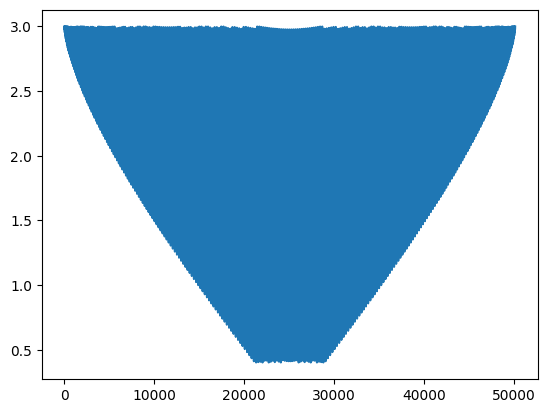

In [10]:
plt.plot(emu.rr_dom)

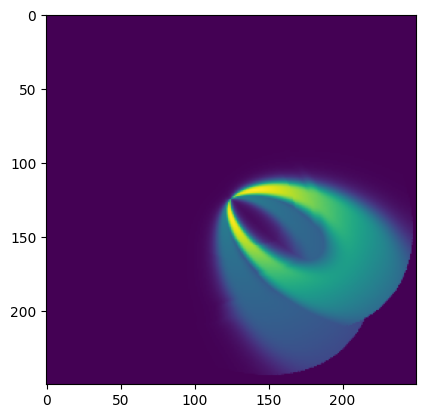

In [8]:
plt.imshow(modelcube.data[60])

# Check that the generation of channel maps at varying parameters is correct

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import fforge
from fforge.inference.emulator import Emulator
from fforge.utils.utils import vr_norm, vaz_norm, generate_ict_128x128_disc_tri_slopes, nullv
import fforge.utils.units as u
from discminer.mining_utils import get_noise_mask, init_data_and_model
from discminer.model import keplerian

#test setup
N = 20
Rp = 261 #au
phip = 57*np.pi/180
testset_cmaps = np.load('cmaps_from_simulations_testset_parfile_R261_phi0.99_hd163296like2.npy')

#setup emulator
labels = ["vphi", "vr"]
pths = [
    "../trained_models/vphi_256/model__epoch_1980_test_vaz_256.pth",
    "../trained_models/vr_256/model__epoch_1980_test_vr_256.pth",
]
params = [
    "../trained_models/vphi_256/params.py",
    "../trained_models/vr_256/params.py",
]

#functions used to denormalize the emulator output
norm_funcs = [vaz_norm, vr_norm]

emu = Emulator(
    model_pths=pths,
    labels=["vphi", "vr"],
    model_params=params,
    norm_funcs=norm_funcs,
    ict_gen=generate_ict_128x128_disc_tri_slopes,
)


def nullv(coord, Mstar=1.0, vel_sign=1, vsys=0, **kwargs):
    Mstar *= u.MSun
    if 'R' not in coord.keys(): R = hypot_func(coord['x'], coord['y'])
    else: R = coord['R']
    return vel_sign*np.sqrt(Mstar/R) * np.nan


#init_discminer
import get_hd163296_refmodel as getmo
model = getmo.get_model().model
model.velocity_func = emu.emulate_v3d

#Case specific parameters. Change to evaluate a different emulator or a different pipeline
testset_data = '../data/data/data/gas_tri_256/datatest.npy'
testset_params = '../data/data/data/gas_tri_256/testpara.csv'
testset = np.load(testset_data)[:,[2,1],::-1]
testparams = pd.read_csv(testset_params, index_col=0)

xy = np.linspace(-3,3,256)
xx, yy = np.meshgrid(xy, xy)
rr = np.sqrt(xx**2+yy**2)
phi = np.arctan2(yy, xx)

mask1 = None
mask2 = None


        


Setting velocity function to <bound method Emulator.emulate_v3d of <fforge.inference.emulator.Emulator object at 0x7f98c7982ef0>>


In [8]:
from tqdm import tqdm
all_emulations = []
parameters = ['Alpha', 'PlanetMass', 'AspectRatio']
grids = {'Alpha': np.logspace(-4,-2,N), 'PlanetMass': np.logspace(-5,-2,N), 'AspectRatio': np.linspace(0.03, 0.1,N)}

mse_varp = {'Alpha': [], 'PlanetMass': [], 'AspectRatio': []}
for i in [19]:
    row = testparams.iloc[i]
    emu_params = {}
    for varied_par in parameters:
        for par in ['Alpha', 'PlanetMass', 'AspectRatio', 'SigmaSlope', 'FlaringIndex']:
            if par == varied_par:
                emu_params[par] = grids[par]
            else:
                emu_params[par] = np.ones(N)*row[par]

        allparams_cmaps = []
        for j in range(N):
            #setup emulator parameters and update emulator velocity function
            emu_params_sing = {
                    "R_p": Rp * u.au,
                    "phi_p": phip,
                    "alpha": emu_params['Alpha'][j],
                    "h": emu_params['AspectRatio'][j],
                    "planetMass": emu_params['PlanetMass'][j],
                    "flaringIndex": emu_params['FlaringIndex'][j],
                    "extrap_vfunc": nullv,
                    "mask_only_ppos": False
             }
        
            model.params['velocity'].update(emu_params_sing)  
            modelcube = model.make_model(make_convolve=True)

            allparams_cmaps.append(modelcube.data)
        allparams_cmaps = np.array(allparams_cmaps)
        mse_varp[varied_par].append([ (((allparams_cmaps - testset_cmaps[i].reshape(1, *testset_cmaps.shape[1:])))**2).mean(axis=(-1,-2)) for mask in [mask1,mask2]])


*====================================================================================================*
Running prototype model with the following parameters:

{'height_lower': {'Rb': 0.03, 'p': 1.09, 'q': 4.18, 'z0': 19.91},
 'height_upper': {'Rb': 4.36, 'p': 1.21, 'q': 1.98, 'z0': 29.78},
 'intensity': {'I0': 0.2574, 'Rout': 380, 'p': -4.16, 'q': 3.68},
 'lineslope': {'Ls': 1.85, 'p': 0.21, 'q': 0.0},
 'linewidth': {'L0': 0.08, 'p': 0.86, 'q': -1.38},
 'orientation': {'PA': 0.7391469382195985,
                 'incl': 0.7977900010866079,
                 'xc': 0.0,
                 'yc': 0.0},
 'velocity': {'Mstar': 1.97,
              'R_p': 39045044252700.0,
              'alpha': np.float64(0.0001),
              'extrap_vfunc': <function nullv at 0x7f98e8167c70>,
              'flaringIndex': np.float64(0.08925),
              'h': np.float64(0.08075),
              'mask_only_ppos': False,
              'phi_p': 0.9948376736367678,
              'planetMass': np.float64(0.0048417

KeyboardInterrupt: 

In [9]:
allparams_cmaps = np.array(allparams_cmaps)

In [10]:
import astropy.units as u

In [5]:
allparams_cmaps* u.Unit(self.header["BUNIT"]).to("beam-1 Jy")

NameError: name 'self' is not defined

In [4]:
allparams_cmaps.shape

(1, 105, 250, 250)

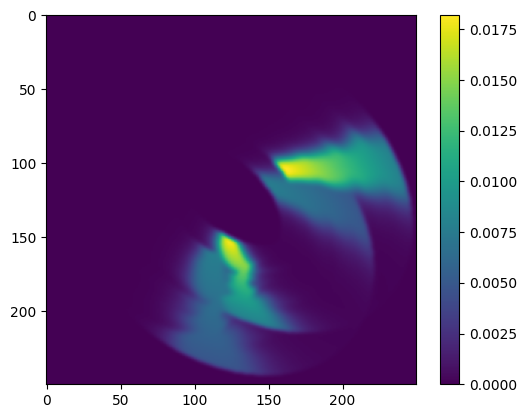

In [10]:
plt.imshow(allparams_cmaps[0,55])
plt.colorbar()

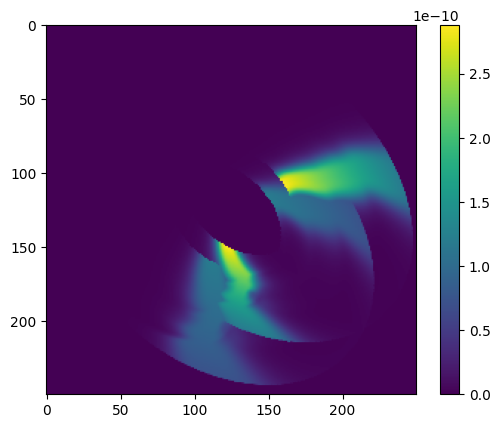

In [13]:
plt.imshow(testset_cmaps[19,53])
plt.colorbar()